# Wine Dataset: Naive Bayes Classifiers

### Task Explanation
In this notebook, the goal is to **apply and compare** two Naive Bayes models on the Wine dataset:
1. **Gaussian Naive Bayes (GNB)**
2. **Multinomial Naive Bayes (MNB)**

We will:
- load and explore the dataset,
- split the data into training and testing sets,
- train both classifiers,
- evaluate their accuracy, and
- identify which model is more suitable for continuous wine features.

## Loading the Wine Dataset

In [666]:
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
import pandas as pd
wine = datasets.load_wine()

## Exploring the Wine Dataset

In [667]:
dir(wine)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [668]:
wine.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [669]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [670]:
wine.data[0:2]

array([[1.423e+01, 1.710e+00, 2.430e+00, 1.560e+01, 1.270e+02, 2.800e+00,
        3.060e+00, 2.800e-01, 2.290e+00, 5.640e+00, 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, 1.120e+01, 1.000e+02, 2.650e+00,
        2.760e+00, 2.600e-01, 1.280e+00, 4.380e+00, 1.050e+00, 3.400e+00,
        1.050e+03]])

In [671]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [672]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [673]:
wine.target[0:2]

array([0, 0])

In [674]:
import pandas as pd
df = pd.DataFrame(wine.data,columns=wine.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


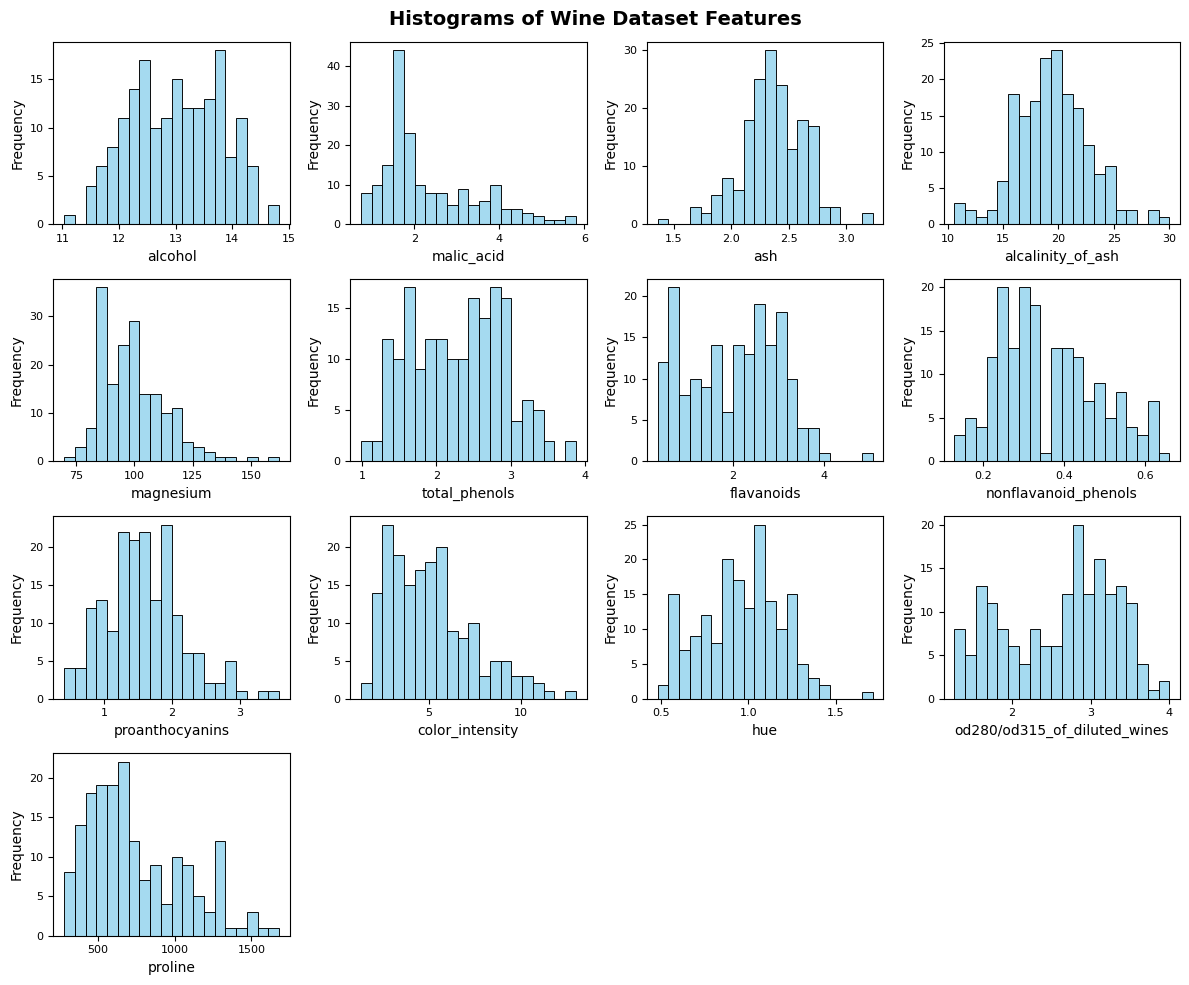

In [675]:

plt.figure(figsize=(12, 10))

# Plot histograms for each feature
for i, column in enumerate(df.columns):
    plt.subplot(4, 4, i + 1)  
    sns.histplot(df[column], bins=20, color='skyblue')
    plt.xlabel(column, fontsize=10)
    plt.ylabel('Frequency')
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

plt.suptitle("Histograms of Wine Dataset Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [676]:
import numpy as np
unique, counts = np.unique(wine.target, return_counts=True)
dict(zip(unique, counts))


{np.int64(0): np.int64(59),
 np.int64(1): np.int64(71),
 np.int64(2): np.int64(48)}

In [677]:
df['target'] = wine.target
df[50:70]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
50,13.05,1.73,2.04,12.4,92.0,2.72,3.27,0.17,2.91,7.20,1.12,2.91,1150.0,0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0,0
52,13.82,1.75,2.42,14.0,111.0,3.88,3.74,0.32,1.87,7.05,1.01,3.26,1190.0,0
53,13.77,1.90,2.68,17.1,115.0,3.00,2.79,0.39,1.68,6.30,1.13,2.93,1375.0,0
54,13.74,1.67,2.25,16.4,118.0,2.60,2.90,0.21,1.62,5.85,0.92,3.20,1060.0,0
55,13.56,1.73,2.46,20.5,116.0,2.96,2.78,0.20,2.45,6.25,0.98,3.03,1120.0,0
56,14.22,1.70,2.30,16.3,118.0,3.20,3.00,0.26,2.03,6.38,0.94,3.31,970.0,0
57,13.29,1.97,2.68,16.8,102.0,3.00,3.23,0.31,1.66,6.00,1.07,2.84,1270.0,0
58,13.72,1.43,2.50,16.7,108.0,3.40,3.67,0.19,2.04,6.80,0.89,2.87,1285.0,0
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,1


## Using `wine.data` and `wine.target` to Train and Test

In [678]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.3, random_state=42)


## Training Gaussian Naive Bayes Classifier

In [679]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)


GaussianNB()

In [680]:
score = gnb.score(X_test, y_test)
print(f"Gaussian Naïve Bayes Accuracy: {score * 100:.2f}%")


Gaussian Naïve Bayes Accuracy: 100.00%


## Training Multinomial Naive Bayes Classifier

In [681]:

from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)



MultinomialNB()

In [682]:
score1 = mnb.score(X_test, y_test)
print(f"Multinomial Naive Bayes Accuracy: {score1 * 100:.2f}%")


Multinomial Naive Bayes Accuracy: 88.89%


## Conclusion
After training both models on the Wine dataset, **Gaussian Naive Bayes** performs better than **Multinomial Naive Bayes** for this problem.

This makes sense because Wine features are mostly **continuous numerical values**, which align with Gaussian Naive Bayes assumptions.

In short: for continuous feature datasets like this one, **Gaussian Naive Bayes is generally the better choice**.